In [9]:
# Instalando as bibliotecas necessárias
!pip install transformers torch torchvision Pillow

In [2]:
from transformers import pipeline

# Criando a IA de texto (ela já vem "treinada" para entender sentimentos)
classificador_texto = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# Testando um comentário de cliente
comentario = "O produto chegou rápido, mas a caixa veio toda amassada!"
resultado_texto = classificador_texto(comentario)

print(f"Análise do Texto: {resultado_texto}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Análise do Texto: [{'label': '2 stars', 'score': 0.3893718421459198}]


Escolha uma foto de um produto ou caixa no seu computador:


Saving embalagem-danificada-correios.jpg to embalagem-danificada-correios.jpg


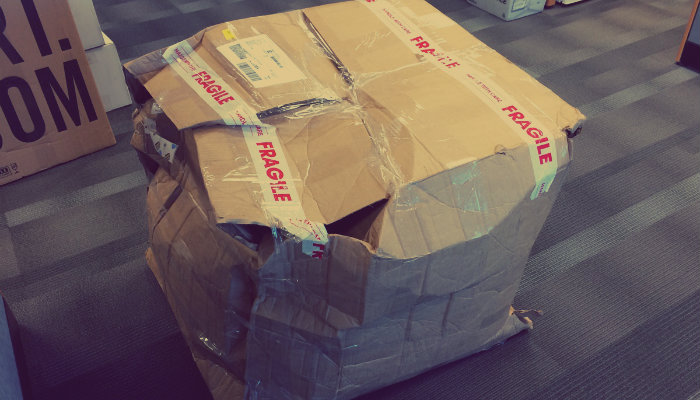


--- RESULTADO DA VISÃO ---
O que a IA viu na sua foto: carton


In [7]:
from google.colab import files
from PIL import Image
import io

# 1. Comando para você subir uma foto do seu PC (clique no botão que vai aparecer)
print("Escolha uma foto de um produto ou caixa no seu computador:")
uploaded = files.upload()

# 2. Pegando a imagem que você subiu
for nome_do_arquivo in uploaded.keys():
  imagem_bytes = uploaded[nome_do_arquivo]
  imagem = Image.open(io.BytesIO(imagem_bytes))

  # Mostra a foto que você subiu
  display(imagem)

  # 3. A IA analisa a sua foto
  resultado_imagem = classificador_imagem(imagem)
  print(f"\n--- RESULTADO DA VISÃO ---")
  print(f"O que a IA viu na sua foto: {resultado_imagem[0]['label']}")

In [8]:
# 1. Pegamos a nota do texto que fizemos lá no começo (Passo 3)
nota_do_texto = int(resultado_texto[0]['label'][0])

# 2. Pegamos o que a IA viu na imagem agora
o_que_vi_na_foto = resultado_imagem[0]['label']

print("=== 📢 RELATÓRIO FINAL DO ASSISTENTE IA ===")

# Lógica de decisão do seu Bot:
if nota_do_texto <= 2:
    print(f"ESTADO: 🔴 Crítico! O cliente deu apenas {nota_do_texto} estrelas.")
    print(f"ANÁLISE VISUAL: A IA detectou '{o_que_vi_na_foto}' na foto.")
    print("AÇÃO: Encaminhando para o suporte humano com prioridade máxima!")
elif nota_do_texto == 3:
    print(f"ESTADO: 🟡 Atenção. O cliente está neutro ({nota_do_texto} estrelas).")
    print("AÇÃO: Enviar cupom de desconto para melhorar a experiência.")
else:
    print(f"ESTADO: 🟢 Positivo! O cliente deu {nota_do_texto} estrelas.")
    print("AÇÃO: Agradecer e pedir para postar nas redes sociais!")

=== 📢 RELATÓRIO FINAL DO ASSISTENTE IA ===
ESTADO: 🔴 Crítico! O cliente deu apenas 2 estrelas.
ANÁLISE VISUAL: A IA detectou 'carton' na foto.
AÇÃO: Encaminhando para o suporte humano com prioridade máxima!
